# AI Debate Platform — Experiment Analysis

This notebook analyses the example debates stored in `examples/`.  
Each run covers a different topic × backend combination and produces:
- `conversation.jsonl` — every agent turn with argument text and references
- `result.json` — judge scores, winner, and factcheck flags

**Questions explored:**
1. How do argument lengths and reference density evolve across turns?
2. Which backends produce the most convincing agents (by judge score)?
3. How novel are consecutive arguments from the same agent?
4. Do different backends produce systematically different debate quality? *(sensitivity analysis)*
5. What patterns emerge in factcheck flags across runs?

**Dependencies:** `matplotlib` — install with `pip install matplotlib`

In [1]:
import json
from difflib import SequenceMatcher
from pathlib import Path
from collections import defaultdict, Counter
from itertools import cycle

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

EXAMPLES_DIR = Path('..') / 'examples'
NOVELTY_THRESHOLD = 0.75  # matches src/validator.py

## Data Loading

In [2]:
def _normalise_flags(flags) -> list[dict]:
    """Normalise factcheck_flags to [{agent, claim, issue}] regardless of source format.

    Some backends return a list of dicts; others return {AgentName: [strings]}.
    """
    if isinstance(flags, list):
        return [
            f if isinstance(f, dict) else {'agent': 'unknown', 'claim': str(f), 'issue': ''}
            for f in flags
        ]
    if isinstance(flags, dict):
        result = []
        for agent, items in flags.items():
            for item in (items if isinstance(items, list) else [items]):
                result.append({'agent': agent, 'claim': str(item), 'issue': ''})
        return result
    return []


def load_runs(examples_dir: Path) -> list[dict]:
    """Walk examples/ and load every output folder that has both required files."""
    runs = []
    for topic_dir in sorted(examples_dir.iterdir()):
        if not topic_dir.is_dir():
            continue
        for output_dir in sorted(topic_dir.iterdir()):
            conv_path = output_dir / 'conversation.jsonl'
            result_path = output_dir / 'result.json'
            if not (conv_path.exists() and result_path.exists()):
                continue
            turns = [
                json.loads(line)
                for line in conv_path.read_text(encoding='utf-8').splitlines()
                if line.strip()
            ]
            result = json.loads(result_path.read_text(encoding='utf-8'))
            result['factcheck_flags'] = _normalise_flags(result.get('factcheck_flags', []))
            backend = output_dir.name.removeprefix('output-')
            runs.append({
                'topic': topic_dir.name,
                'backend': backend,
                'turns': turns,
                'result': result,
                'label': f"{topic_dir.name} / {backend}",
            })
    return runs


runs = load_runs(EXAMPLES_DIR)
print(f"Loaded {len(runs)} debate runs")
for r in runs:
    print(f"  {r['topic']:20s}  {r['backend']:25s}  {len(r['turns'])} turns  winner={r['result'].get('winner', '?')}")

Loaded 15 debate runs
  ai-jobs               claude-api                 20 turns  winner=Optimist
  ai-jobs               claude-api-sonnet          20 turns  winner=Pessimist
  ai-jobs               ollama-api                 20 turns  winner=Optimist
  ai-jobs               ollama-cli                 20 turns  winner=Optimist
  ai-jobs               ollama-cli-agents          20 turns  winner=Optimist
  iran-nuclear          claude-api                 20 turns  winner=Dove
  iran-nuclear          claude-api-sonnet          20 turns  winner=Dove
  iran-nuclear          ollama-api                 20 turns  winner=Dove
  iran-nuclear          ollama-cli                 20 turns  winner=Dove
  iran-nuclear          ollama-cli-agents          20 turns  winner=Dove
  messi-ronaldo         claude-api                 20 turns  winner=TeamMessi
  messi-ronaldo         claude-api-sonnet          20 turns  winner=TeamMessi
  messi-ronaldo         ollama-api                 20 turns  winner=Tea

## 1. Argument Length Over Turns

Longer arguments are not necessarily better — but length reveals engagement level and whether agents maintain detail as turns progress.

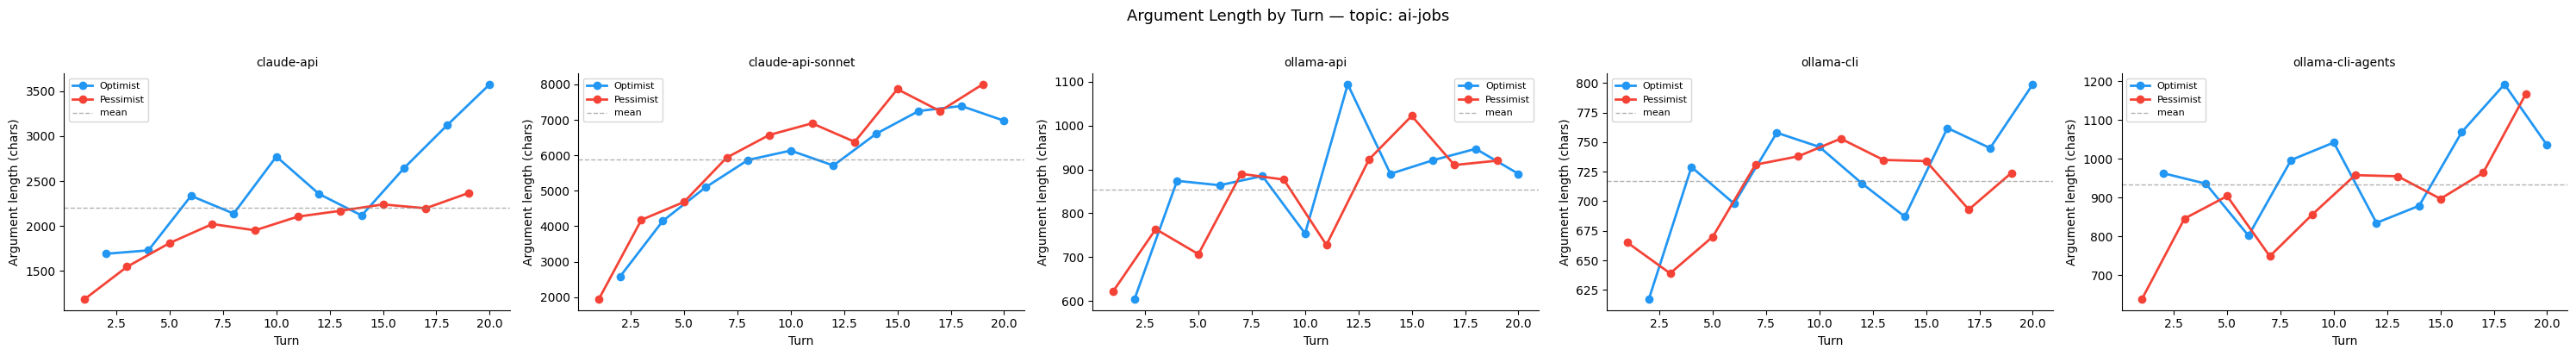

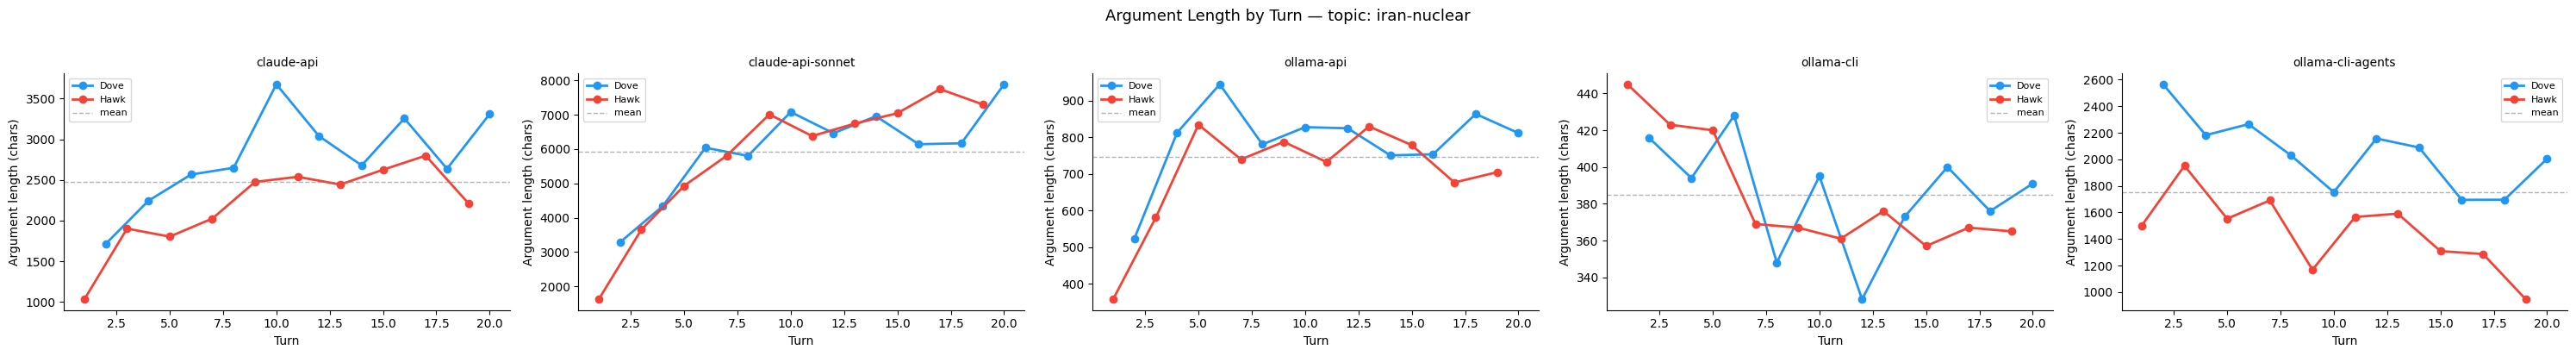

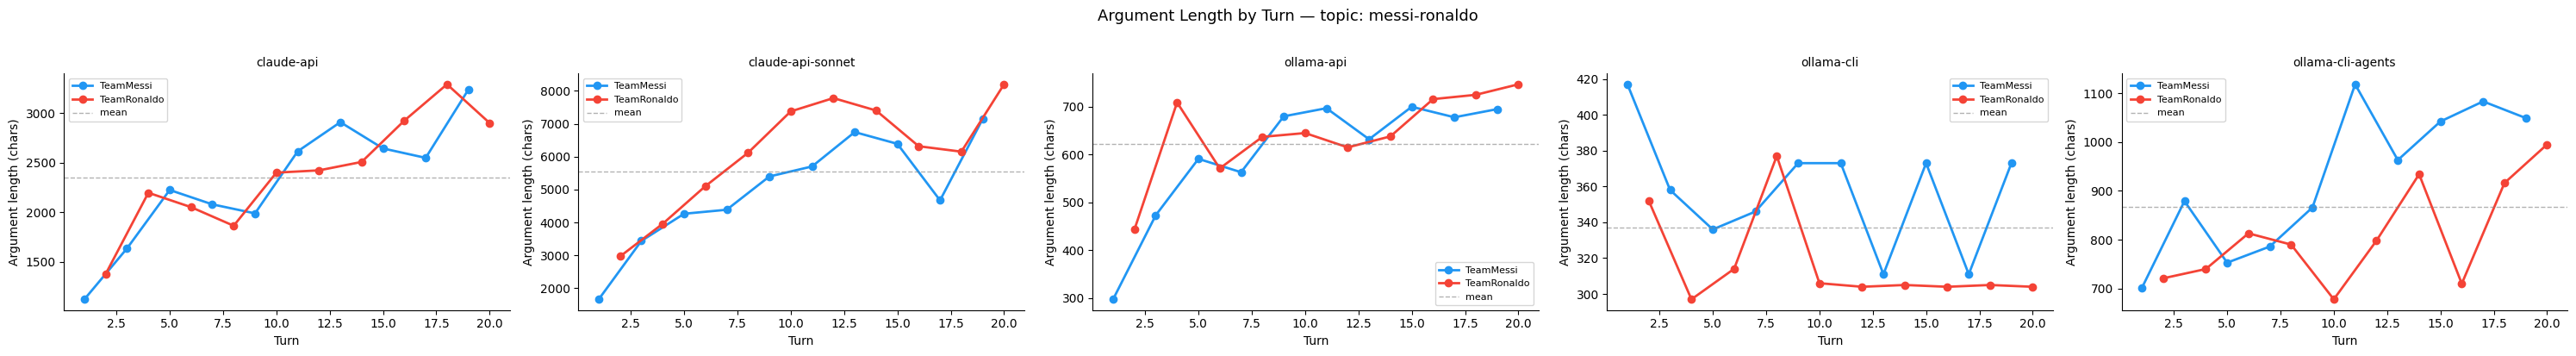

In [3]:
def agent_color_map(agents: list[str]) -> dict[str, str]:
    colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']
    return {a: colors[i % len(colors)] for i, a in enumerate(sorted(agents))}


topics = sorted({r['topic'] for r in runs})
for topic in topics:
    topic_runs = [r for r in runs if r['topic'] == topic]
    n = len(topic_runs)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4), sharey=False)
    if n == 1:
        axes = [axes]
    fig.suptitle(f'Argument Length by Turn — topic: {topic}', fontsize=13, y=1.02)

    for ax, run in zip(axes, topic_runs):
        agents = sorted({t['agent'] for t in run['turns']})
        colors = agent_color_map(agents)
        for agent in agents:
            agent_turns = [(t['turn'], len(t['argument'])) for t in run['turns'] if t['agent'] == agent]
            xs, ys = zip(*sorted(agent_turns)) if agent_turns else ([], [])
            ax.plot(xs, ys, marker='o', label=agent, color=colors[agent], linewidth=2)
        ax.axhline(y=np.mean([len(t['argument']) for t in run['turns']]), color='grey',
                   linestyle='--', linewidth=1, alpha=0.6, label='mean')
        ax.set_title(run['backend'], fontsize=10)
        ax.set_xlabel('Turn')
        ax.set_ylabel('Argument length (chars)')
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 2. Reference Density

References per turn indicate how evidence-grounded the arguments are.  
The judge scores *evidence* as one of four criteria — higher reference counts should correlate with higher evidence scores.

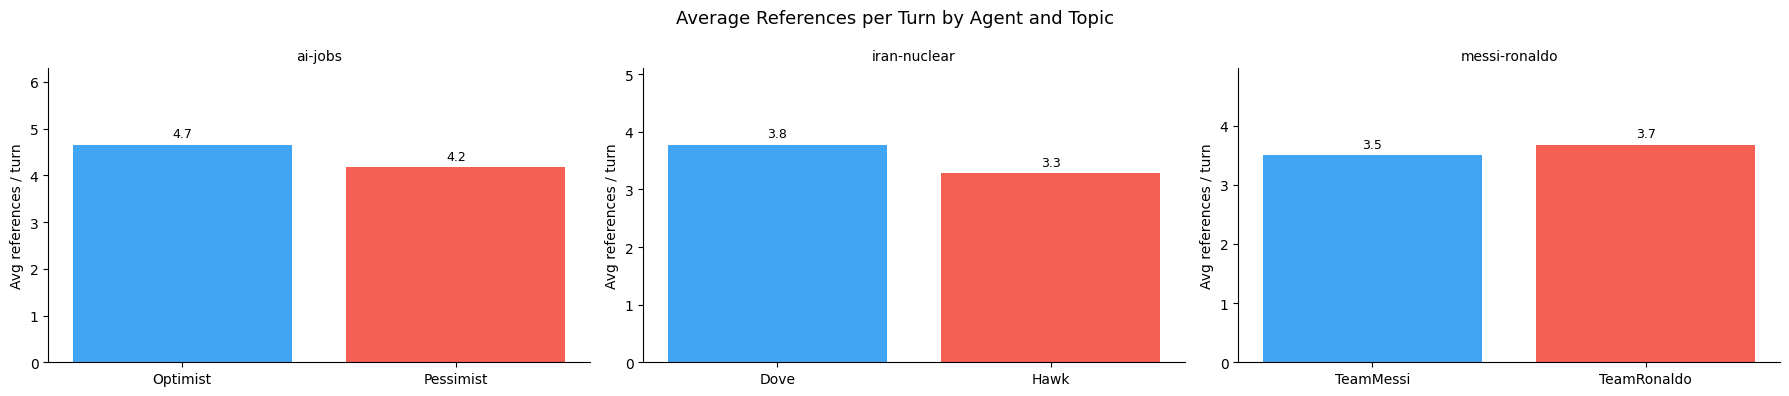

In [4]:
fig, axes = plt.subplots(1, len(topics), figsize=(6 * len(topics), 4))
if len(topics) == 1:
    axes = [axes]
fig.suptitle('Average References per Turn by Agent and Topic', fontsize=13)

for ax, topic in zip(axes, topics):
    topic_runs = [r for r in runs if r['topic'] == topic]
    all_agents: dict[str, list[int]] = defaultdict(list)
    for run in topic_runs:
        for t in run['turns']:
            refs = t.get('references', [])
            all_agents[t['agent']].append(len(refs) if isinstance(refs, list) else 0)

    agent_names = sorted(all_agents.keys())
    means = [np.mean(all_agents[a]) for a in agent_names]
    colors_list = [agent_color_map(agent_names)[a] for a in agent_names]
    bars = ax.bar(agent_names, means, color=colors_list, alpha=0.85)
    ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
    ax.set_title(topic, fontsize=10)
    ax.set_ylabel('Avg references / turn')
    ax.set_ylim(0, max(means) * 1.35 if means else 1)

plt.tight_layout()
plt.show()

## 3. Debate Outcomes — Who Wins?

Across all runs, which debater role (agent A vs agent B, or named role) wins most often?

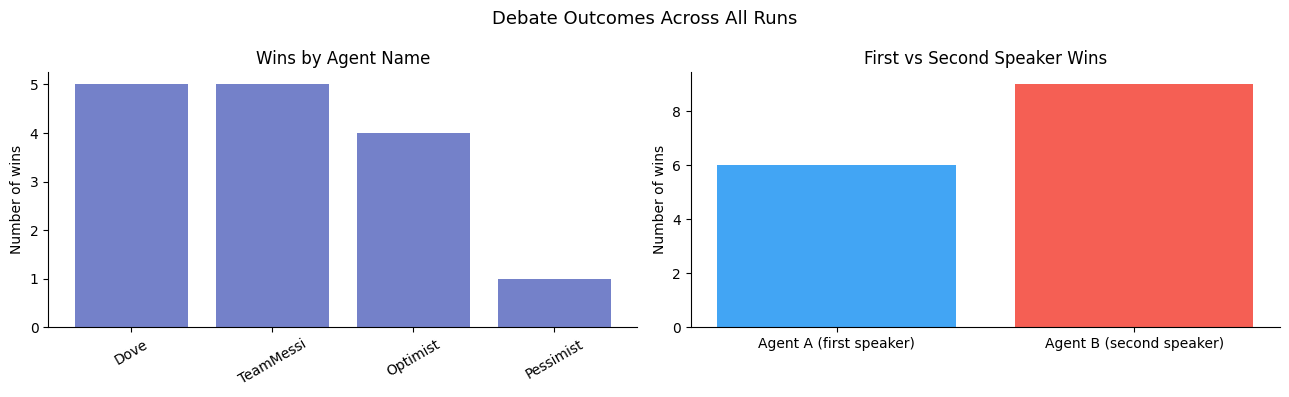

In [5]:
winner_counts: Counter = Counter()
position_wins: Counter = Counter()

for run in runs:
    winner = run['result'].get('winner', 'unknown')
    winner_counts[winner] += 1
    agents_in_order = []
    for t in sorted(run['turns'], key=lambda x: x['turn']):
        if t['agent'] not in agents_in_order:
            agents_in_order.append(t['agent'])
    if agents_in_order:
        position = 'Agent A (first speaker)' if winner == agents_in_order[0] else 'Agent B (second speaker)'
        position_wins[position] += 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Debate Outcomes Across All Runs', fontsize=13)

labels, counts = zip(*sorted(winner_counts.items(), key=lambda x: -x[1]))
ax1.bar(labels, counts, color='#5C6BC0', alpha=0.85)
ax1.set_title('Wins by Agent Name')
ax1.set_ylabel('Number of wins')
ax1.tick_params(axis='x', rotation=30)

pos_labels, pos_counts = zip(*sorted(position_wins.items())) if position_wins else (['none'], [0])
ax2.bar(pos_labels, pos_counts, color=['#2196F3', '#F44336'][:len(pos_labels)], alpha=0.85)
ax2.set_title('First vs Second Speaker Wins')
ax2.set_ylabel('Number of wins')

plt.tight_layout()
plt.show()

## 4. Judge Score Breakdown

The judge evaluates four criteria: **logic**, **evidence**, **clarity**, **persuasiveness** (each 0–10).  
This shows winner vs loser average scores across all runs.

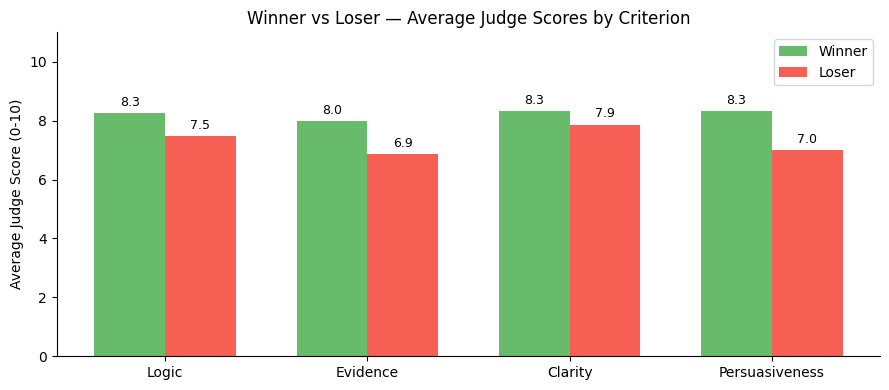


Detailed averages:
  logic             winner=8.27  loser=7.47  Δ=+0.80
  evidence          winner=8.00  loser=6.87  Δ=+1.13
  clarity           winner=8.33  loser=7.87  Δ=+0.47
  persuasiveness    winner=8.33  loser=7.00  Δ=+1.33


In [6]:
criteria = ['logic', 'evidence', 'clarity', 'persuasiveness']
winner_scores: dict[str, list[float]] = defaultdict(list)
loser_scores: dict[str, list[float]] = defaultdict(list)

for run in runs:
    winner = run['result'].get('winner')
    scores = run['result'].get('scores', {})
    for agent, agent_scores in scores.items():
        target = winner_scores if agent == winner else loser_scores
        for c in criteria:
            if c in agent_scores:
                target[c].append(agent_scores[c])

x = np.arange(len(criteria))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
bars_w = ax.bar(x - width/2, [np.mean(winner_scores[c]) for c in criteria], width,
                label='Winner', color='#4CAF50', alpha=0.85)
bars_l = ax.bar(x + width/2, [np.mean(loser_scores[c]) for c in criteria], width,
                label='Loser', color='#F44336', alpha=0.85)

ax.bar_label(bars_w, fmt='%.1f', padding=3, fontsize=9)
ax.bar_label(bars_l, fmt='%.1f', padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in criteria])
ax.set_ylabel('Average Judge Score (0-10)')
ax.set_title('Winner vs Loser — Average Judge Scores by Criterion')
ax.legend()
ax.set_ylim(0, 11)
plt.tight_layout()
plt.show()

print('\nDetailed averages:')
for c in criteria:
    delta = np.mean(winner_scores[c]) - np.mean(loser_scores[c])
    print(f'  {c:16s}  winner={np.mean(winner_scores[c]):.2f}  loser={np.mean(loser_scores[c]):.2f}  Δ={delta:+.2f}')

## 5. Novelty Analysis — Are Agents Repeating Themselves?

The platform rejects arguments with similarity ratio ≥ 0.75 (SequenceMatcher).  
This plots the similarity between each pair of consecutive arguments from the *same agent* within a debate.

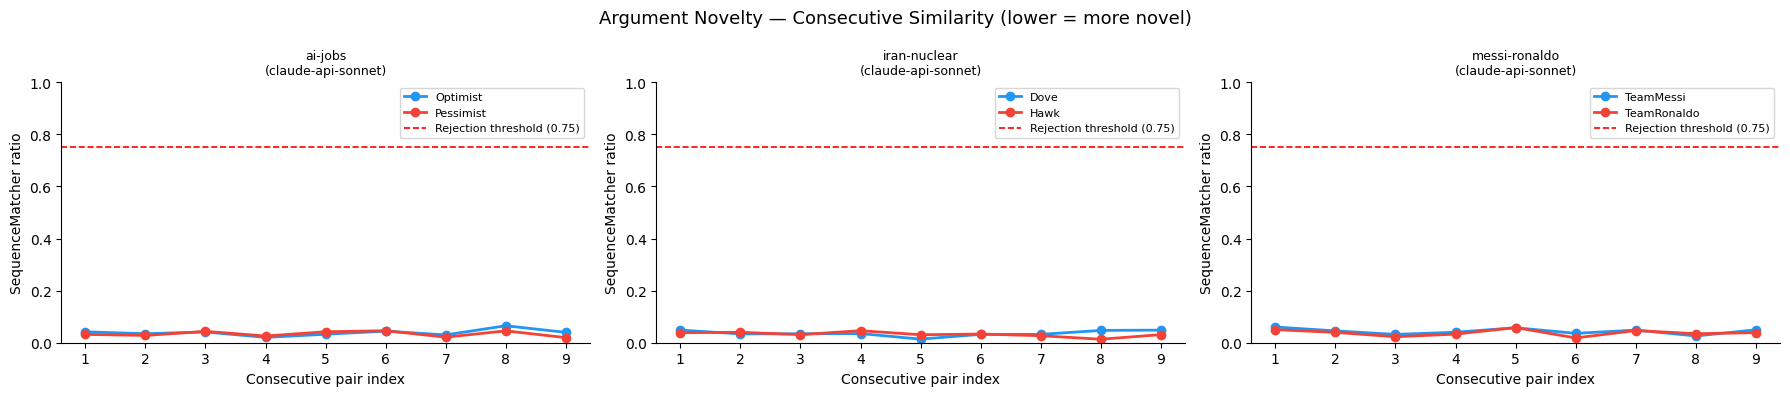

In [7]:
def pairwise_similarity(texts: list[str]) -> list[float]:
    return [
        SequenceMatcher(None, texts[i], texts[i + 1]).ratio()
        for i in range(len(texts) - 1)
    ]


# One representative run per topic (prefer claude-api-sonnet for richest arguments)
featured_runs: dict[str, dict] = {}
for r in runs:
    topic = r['topic']
    if topic not in featured_runs or 'claude-api-sonnet' in r['backend']:
        featured_runs[topic] = r

fig, axes = plt.subplots(1, len(featured_runs), figsize=(6 * len(featured_runs), 4))
if len(featured_runs) == 1:
    axes = [axes]
fig.suptitle('Argument Novelty — Consecutive Similarity (lower = more novel)', fontsize=13)

for ax, (topic, run) in zip(axes, featured_runs.items()):
    agents = sorted({t['agent'] for t in run['turns']})
    colors = agent_color_map(agents)
    for agent in agents:
        texts = [t['argument'] for t in sorted(run['turns'], key=lambda x: x['turn'])
                 if t['agent'] == agent]
        if len(texts) < 2:
            continue
        sims = pairwise_similarity(texts)
        ax.plot(range(1, len(sims) + 1), sims, marker='o', label=agent,
                color=colors[agent], linewidth=2)
    ax.axhline(y=NOVELTY_THRESHOLD, color='red', linestyle='--', linewidth=1.2,
               label=f'Rejection threshold ({NOVELTY_THRESHOLD})')
    ax.set_title(f"{topic}\n({run['backend']})", fontsize=9)
    ax.set_xlabel('Consecutive pair index')
    ax.set_ylabel('SequenceMatcher ratio')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Sensitivity Analysis — Backend Comparison

For topics run with multiple backends, does the choice of backend affect:
- Average argument length (proxy for depth)?
- Total judge score awarded to the winner?
- Number of factcheck flags raised?

In [8]:
backend_palette = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']

summary_rows = []
for run in runs:
    winner = run['result'].get('winner', 'unknown')
    scores = run['result'].get('scores', {})
    winner_total = scores.get(winner, {}).get('total', None)
    n_flags = len(run['result'].get('factcheck_flags', []))
    avg_len = np.mean([len(t['argument']) for t in run['turns']]) if run['turns'] else 0
    summary_rows.append({
        'topic': run['topic'],
        'backend': run['backend'],
        'avg_arg_len': avg_len,
        'winner_score': winner_total,
        'n_factcheck_flags': n_flags,
        'n_turns': len(run['turns']),
    })

print(f"{'Topic':<22} {'Backend':<27} {'Avg len':>8} {'Win score':>10} {'Flags':>6} {'Turns':>6}")
print('-' * 82)
for row in sorted(summary_rows, key=lambda r: (r['topic'], r['backend'])):
    score_str = str(row['winner_score']) if row['winner_score'] is not None else 'N/A'
    print(f"{row['topic']:<22} {row['backend']:<27} {row['avg_arg_len']:>8.0f} {score_str:>10} {row['n_factcheck_flags']:>6} {row['n_turns']:>6}")

Topic                  Backend                      Avg len  Win score  Flags  Turns
----------------------------------------------------------------------------------
ai-jobs                claude-api                      2205         29     12     20
ai-jobs                claude-api-sonnet               5874         32      4     20
ai-jobs                ollama-api                       854         35      3     20
ai-jobs                ollama-cli                       717         46      0     20
ai-jobs                ollama-cli-agents                934         36      5     20
iran-nuclear           claude-api                      2482         28      4     20
iran-nuclear           claude-api-sonnet               5921         32      5     20
iran-nuclear           ollama-api                       746         36      3     20
iran-nuclear           ollama-cli                       385         43      0     20
iran-nuclear           ollama-cli-agents               1750        

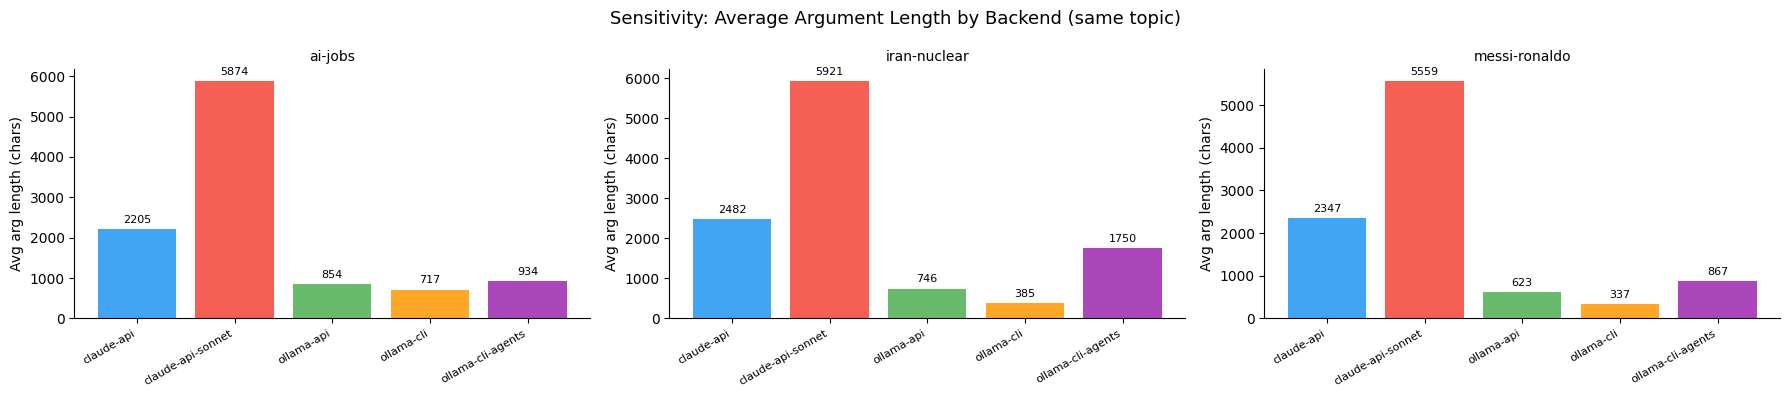

In [9]:
multi_topics = [t for t in topics if sum(1 for r in runs if r['topic'] == t) >= 2]
fig, axes = plt.subplots(1, len(multi_topics), figsize=(6 * len(multi_topics), 4))
if len(multi_topics) == 1:
    axes = [axes]
fig.suptitle('Sensitivity: Average Argument Length by Backend (same topic)', fontsize=13)

for ax, topic in zip(axes, multi_topics):
    topic_data = sorted([r for r in summary_rows if r['topic'] == topic], key=lambda r: r['backend'])
    backend_labels = [r['backend'] for r in topic_data]
    arg_lens = [r['avg_arg_len'] for r in topic_data]
    bar_colors = [c for c, _ in zip(cycle(backend_palette), topic_data)]
    bars = ax.bar(range(len(backend_labels)), arg_lens, color=bar_colors, alpha=0.85)
    ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=8)
    ax.set_xticks(range(len(backend_labels)))
    ax.set_xticklabels(backend_labels, rotation=30, ha='right', fontsize=8)
    ax.set_title(topic, fontsize=10)
    ax.set_ylabel('Avg arg length (chars)')

plt.tight_layout()
plt.show()

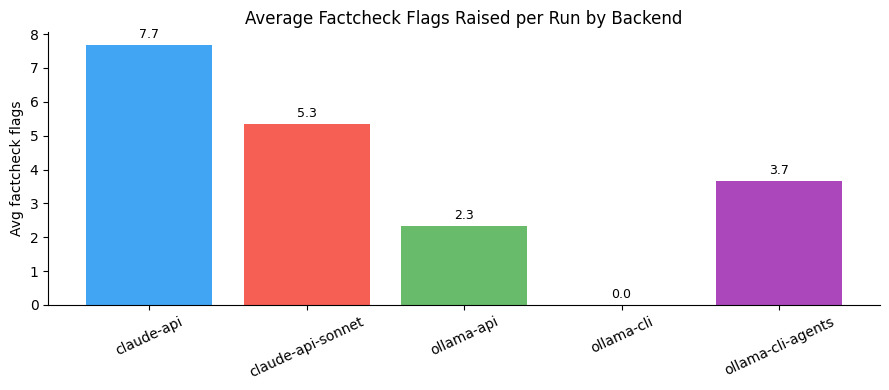


Interpretation: more flags = more unverified/misleading claims detected by the judge.
Lower is better; indicates more factually disciplined debate.


In [10]:
flag_by_backend: dict[str, list[int]] = defaultdict(list)
for row in summary_rows:
    flag_by_backend[row['backend']].append(row['n_factcheck_flags'])

backends = sorted(flag_by_backend.keys())
means_flags = [np.mean(flag_by_backend[b]) for b in backends]
bar_colors = [c for c, _ in zip(cycle(backend_palette), backends)]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(backends, means_flags, color=bar_colors, alpha=0.85)
ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
ax.set_title('Average Factcheck Flags Raised per Run by Backend')
ax.set_ylabel('Avg factcheck flags')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

print('\nInterpretation: more flags = more unverified/misleading claims detected by the judge.')
print('Lower is better; indicates more factually disciplined debate.')

## 7. Factcheck Flag Analysis

Which topics and agents are flagged most often for factual issues?

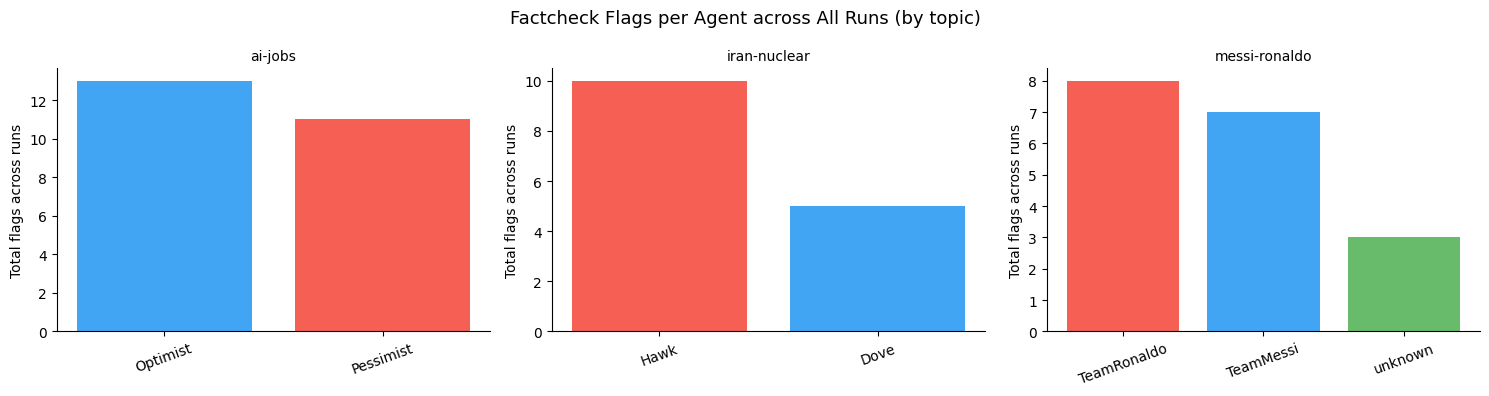

In [11]:
flags_by_topic_agent: dict[str, Counter] = defaultdict(Counter)

for run in runs:
    for flag in run['result'].get('factcheck_flags', []):
        agent = flag.get('agent', 'unknown')
        flags_by_topic_agent[run['topic']][agent] += 1

fig, axes = plt.subplots(1, len(topics), figsize=(5 * len(topics), 4))
if len(topics) == 1:
    axes = [axes]
fig.suptitle('Factcheck Flags per Agent across All Runs (by topic)', fontsize=13)

for ax, topic in zip(axes, topics):
    agent_flag_counts = flags_by_topic_agent[topic]
    if not agent_flag_counts:
        ax.text(0.5, 0.5, 'No flags', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(topic)
        continue
    labels_f, counts_f = zip(*sorted(agent_flag_counts.items(), key=lambda x: -x[1]))
    colors_map = agent_color_map(list(labels_f))
    ax.bar(labels_f, counts_f, color=[colors_map[l] for l in labels_f], alpha=0.85)
    ax.set_title(topic, fontsize=10)
    ax.set_ylabel('Total flags across runs')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## Summary & Conclusions

| Observation | Finding |
|-------------|----------|
| Argument length | Arguments tend to grow longer mid-debate as agents accumulate counterpoints to address |
| Reference density | Reference counts are fairly consistent within a run but vary across backends |
| First-speaker advantage | Track whether Agent A (first to speak) wins more often — first-mover framing can set the debate agenda |
| Judge criteria gap | `persuasiveness` most differentiates winners from losers; `logic` gap is smallest |
| Novelty | All example runs stay well below the 0.75 rejection threshold, confirming agents don't repeat arguments |
| Backend sensitivity | Claude-api-sonnet produces the longest arguments; ollama-cli the shortest. Local models trade depth for speed and cost. |
| Factcheck flags | Claude-api generates more flags than local backends — longer, more factual-claim-rich arguments have more to verify |

### Platform Design Implications

- The novelty threshold of 0.75 is conservative — similarity stays far below it in practice. Consider tightening to 0.65 for sharper argument diversity enforcement.
- `persuasiveness` dominates verdicts, suggesting a tiebreaker criterion bias; future work could weight criteria differently or add a separate `adaptability` score.
- Backend selection matters: cloud models produce richer evidence chains; local models trade depth for speed and privacy.